# Futures Session Aggregation: Hourly to Daily

**Docker image**: `ml4t`

**Purpose**: Convert hourly continuous futures bars (Databento, UTC) to
session-aware daily bars that respect the 4:00 PM Central Time CME session
boundary, applying ratio back-adjustment to eliminate roll-induced price
gaps.

**Learning objectives**:

- Understand why CME session dates differ from UTC calendar dates and how
  bars on Sunday evening belong to Monday's session.
- Apply ratio (multiplicative) back-adjustment to a continuous series so
  percentage returns are preserved across rolls.
- Aggregate hourly bars to session-correct daily OHLCV across all 30 products
  and three tenors (front month, first deferred, second deferred).

**Book reference**: §2.2 ("The Asset-Class Market Data Landscape" — Futures);
adjustment methodology compared in `06_futures_continuous`.

**Prerequisites**: `data` package on `PYTHONPATH`; hourly continuous parquet
present at `ML4T_DATA_PATH/futures/market/continuous/`. See
[`06_futures_continuous`](06_futures_continuous.ipynb) for the teaching
explanation of ratio vs Panama adjustment.

In [1]:
"""Session-aware aggregation of hourly futures to daily bars."""

import os
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_cme_futures
from utils import ML4T_DATA_PATH
from utils.paths import REPO_ROOT, get_chapter_dir
from utils.style import COLORS, ml4t_palette


def _rel(path):
    """Repo-relative display path (keeps absolute machine paths out of outputs)."""
    try:
        return path.relative_to(REPO_ROOT)
    except ValueError:
        return path

In [2]:
# WRITE_TO_DATA=1 materializes the canonical daily parquet under ML4T_DATA_PATH
# for the downstream chapters and case studies; the default (0) writes to a
# chapter-local output dir so a demo run never overwrites production data.
WRITE_TO_DATA = os.environ.get("WRITE_TO_DATA", "0") == "1"

In [3]:
# Output path for the session-aggregated daily data, selected by WRITE_TO_DATA.
OUTPUT_DIR = (
    ML4T_DATA_PATH / "futures" / "market" / "continuous" / "daily"
    if WRITE_TO_DATA
    else get_chapter_dir(2) / "output" / "futures_daily"
)

## 1. CME Session Boundaries

### Session Definition

CME Globex sessions follow this schedule:
- **Session Start**: Sunday 5:00 PM CT (for Monday session)
- **Session End**: 4:00 PM CT (defines the session date)
- **Daily Maintenance**: 4:00-5:00 PM CT (1-hour break)

### Why This Matters

If we aggregate by calendar day (midnight UTC), we split a single trading
session across two days, creating incorrect daily bars:

| Approach | Sunday 11 PM UTC | Monday 3 PM UTC |
|----------|------------------|-----------------|
| **Calendar Day (Wrong)** | Sunday | Monday |
| **CME Session (Correct)** | Monday | Monday |

Both bars belong to Monday's session (which ends Monday 4 PM CT).

### Exkurs: Was ist UTC als Zeitzone?

**UTC** (Coordinated Universal Time) ist der weltweite Referenz-Zeitstandard,
von dem sich alle Zeitzonen als fester Offset ableiten (z. B. `UTC+1` für
Mitteleuropa im Winter, `UTC-5`/`UTC-6` für Chicago). Im Gegensatz zu lokalen
Zeitzonen wie `America/Chicago` kennt UTC **keine Sommerzeitumstellung** — es
läuft ganzjährig gleichmäßig durch.

Genau deshalb sind die Rohdaten hier (Databento) in UTC gespeichert, nicht in
CT:

- **Eindeutigkeit**: CME-Futures handeln in Chicago, aber Databento liefert
  die Daten global. Ohne festen Referenzpunkt wäre unklar, ob ein Timestamp
  Lokalzeit, Exchange-Zeit oder Serverzeit meint.
- **Keine Sommerzeit-Sprünge**: `America/Chicago` springt zweimal im Jahr um
  eine Stunde (CST ↔ CDT). Das würde bei Zeitreihenoperationen — Sortierung,
  Differenzen zwischen Timestamps, Session-Grenzen — zu Doppel- oder
  Lücken-Stunden führen. UTC ist dafür immun.
- **Session-Alignment ist trotzdem lokal nötig**: CME-Sessions enden um 16:00
  **CT**, nicht um Mitternacht UTC — deshalb konvertiert
  `assign_cme_session_date()` unten (`ts.astimezone(CT)`) jeden UTC-Timestamp
  gezielt nach Central Time, nur um die Session-Grenze zu bestimmen. Der
  zugrunde liegende UTC-Wert selbst bleibt dabei unverändert; `astimezone`
  ändert nur die *Anzeige*/Interpretation, nicht den absoluten Zeitpunkt.

Das ist der Standard-Pattern in diesem Projekt: intern/gespeichert immer UTC,
nur für Session-/Anzeige-Logik lokal umrechnen.

In [4]:
# Timezone constants
CT = ZoneInfo("America/Chicago")
UTC = ZoneInfo("UTC")

# CME session ends at 4 PM CT
SESSION_END_HOUR_CT = 16  # 4:00 PM


def assign_cme_session_date(ts: datetime) -> datetime:
    """
    Assign CME session date to a UTC timestamp.

    The session date is the date when the session ENDS (4 PM CT).
    A bar at Sunday 11 PM UTC belongs to Monday's session.

    CME closes Friday at 4 PM CT and reopens Sunday 5 PM CT.
    Bars after Friday 4 PM CT still belong to Friday's session —
    they must NOT roll to Saturday.

    Args:
        ts: UTC timestamp

    Returns:
        Session date (as date, no time component)
    """
    # Convert to Central Time
    ts_ct = ts.astimezone(CT)

    # If we're past 4 PM CT, this belongs to tomorrow's session
    if ts_ct.hour >= SESSION_END_HOUR_CT:
        candidate = ts_ct.date() + timedelta(days=1)
        # Friday after 4 PM CT → keep as Friday (no Saturday session)
        # isoweekday: Mon=1, Fri=5, Sat=6
        if candidate.isoweekday() == 6:  # Saturday
            candidate = ts_ct.date()  # Keep as Friday
        session_date = candidate
    else:
        session_date = ts_ct.date()

    return session_date

In [5]:
# Quick test
test_times = [
    datetime(2024, 1, 7, 23, 0, tzinfo=UTC),  # Sunday 11 PM UTC = Sunday 5 PM CT -> Monday
    datetime(2024, 1, 8, 15, 0, tzinfo=UTC),  # Monday 3 PM UTC = Monday 9 AM CT -> Monday
    datetime(2024, 1, 8, 22, 0, tzinfo=UTC),  # Monday 10 PM UTC = Monday 4 PM CT -> Tuesday
    datetime(
        2024, 1, 12, 22, 0, tzinfo=UTC
    ),  # Friday 10 PM UTC = Friday 4 PM CT -> Friday (NOT Saturday)
]

print("Session Assignment Examples:")
for ts in test_times:
    ts_ct = ts.astimezone(CT)
    session = assign_cme_session_date(ts)
    print(f"  {ts} ({ts_ct.strftime('%a %I:%M %p CT')}) -> Session: {session}")

Session Assignment Examples:
  2024-01-07 23:00:00+00:00 (Sun 05:00 PM CT) -> Session: 2024-01-08
  2024-01-08 15:00:00+00:00 (Mon 09:00 AM CT) -> Session: 2024-01-08
  2024-01-08 22:00:00+00:00 (Mon 04:00 PM CT) -> Session: 2024-01-09
  2024-01-12 22:00:00+00:00 (Fri 04:00 PM CT) -> Session: 2024-01-12


## 2. Load Hourly Continuous Data

We load all products and tenors from the DataBento hourly data.

In [6]:
hourly = load_cme_futures(continuous=True, frequency="hourly")
products = sorted(hourly["product"].unique().to_list())

print(f"Loaded {len(hourly):,} hourly bars")
print(f"Products: {hourly['product'].n_unique()}")
print(f"Tenors: {sorted(hourly['tenor'].unique().to_list())}")
print(f"Date range: {hourly['timestamp'].min()} to {hourly['timestamp'].max()}")
print(f"Available products: {', '.join(products)}")

Loaded 2,672,391 hourly bars
Products: 14
Tenors: [0, 1, 2]
Date range: 2011-01-02 23:00:00+00:00 to 2025-12-30 23:00:00+00:00
Available products: CL, ES, GC, HO, NG, NQ, RB, RTY, SI, YM, ZB, ZF, ZN, ZT


In [7]:
hourly.filter(pl.col("product") == "ES").select(
    "timestamp", "product", "tenor", "open", "high", "low", "close", "volume"
).head(10)

timestamp,product,tenor,open,high,low,close,volume
"datetime[ns, UTC]",str,i8,f64,f64,f64,f64,u64
2011-01-02 23:00:00 UTC,"""ES""",0,1256.0,1257.75,1255.25,1256.75,7479
2011-01-02 23:00:00 UTC,"""ES""",1,1250.75,1250.75,1250.75,1250.75,5
2011-01-02 23:00:00 UTC,"""ES""",2,1248.0,1248.0,1248.0,1248.0,5
2011-01-03 00:00:00 UTC,"""ES""",0,1256.75,1257.5,1255.75,1257.0,2715
2011-01-03 00:00:00 UTC,"""ES""",1,1251.5,1251.5,1251.5,1251.5,3
2011-01-03 01:00:00 UTC,"""ES""",0,1257.0,1257.25,1256.75,1257.0,2095
2011-01-03 01:00:00 UTC,"""ES""",1,1252.0,1252.25,1252.0,1252.25,2
2011-01-03 02:00:00 UTC,"""ES""",0,1257.0,1257.5,1256.75,1257.25,1556
2011-01-03 03:00:00 UTC,"""ES""",0,1257.25,1261.0,1257.25,1260.25,6798


## 3. Assign Session Dates

We add a `session_date` column using Polars expressions for efficiency.

### Exkurs: Wie funktioniert `add_session_date()`?

Das ist die **vektorisierte Polars-Version** von `assign_cme_session_date()`
weiter oben — statt einen einzelnen `datetime` zu verarbeiten, hängt sie eine
`session_date`-Spalte an einen ganzen DataFrame, ohne eine Python-Schleife
über Millionen Zeilen zu laufen.

**1. UTC → Central Time konvertieren**

```python
df.with_columns(pl.col("timestamp").dt.convert_time_zone("America/Chicago").alias("ts_ct"))
```

Wie im UTC-Exkurs oben erklärt: `timestamp` bleibt UTC-basiert, `convert_time_zone`
erzeugt nur eine zusätzliche Spalte mit der lokalen CT-Ansicht desselben
Zeitpunkts (inkl. automatischer CST/CDT-Sommerzeit-Berücksichtigung, da
`America/Chicago` eine echte IANA-Zeitzone ist, kein fixer Offset).

**2. Drei Hilfsspalten ableiten**

```python
pl.col("ts_ct").dt.date().alias("_ct_date"),                              # Kalenderdatum in CT
(pl.col("ts_ct").dt.hour() >= SESSION_END_HOUR_CT).alias("_after_close"),  # nach 16 Uhr CT?
(pl.col("ts_ct").dt.weekday() == 5).alias("_is_friday"),                   # Freitag?
```

`SESSION_END_HOUR_CT = 16` ist oben als Konstante definiert. `dt.weekday()`
liefert in Polars 1=Montag...7=Sonntag, also `== 5` für Freitag.

**3. Die eigentliche Regel anwenden**

```python
pl.when(pl.col("_after_close") & ~pl.col("_is_friday"))
.then(pl.col("_ct_date") + pl.duration(days=1))
.otherwise(pl.col("_ct_date"))
.alias("session_date")
```

In Worten: *Ist die Bar nach 16 Uhr CT UND kein Freitag → gehört sie zum
nächsten Kalendertag. Sonst (vor 16 Uhr, oder Freitag nach 16 Uhr) → bleibt
sie beim aktuellen Datum.*

Der Freitags-Sonderfall ist der Grund für die Ausnahme: Ohne sie würde eine
Bar von Freitag 17 Uhr CT auf „Samstag" rollen — aber CME hat **keine
Samstags-Session** (Handel schließt Freitag 16 Uhr, öffnet erst wieder
Sonntag 17 Uhr). Die letzte Handelsstunde vor dem Wochenende muss deshalb bei
Freitag bleiben, nicht auf einen nicht-existenten Handelstag rutschen — genau
das validiert weiter oben `test_times[3]` (Kommentar „NOT Saturday").

**4. Aufräumen**

```python
.drop("ts_ct", "_ct_date", "_after_close", "_is_friday")
```

Die Hilfsspalten (Unterstrich-Präfix als Konvention für „intern/temporär")
werden entfernt — übrig bleibt nur die neue `session_date`-Spalte neben den
ursprünglichen.

**Warum diese Version statt der Skalar-Funktion:** `assign_cme_session_date()`
nimmt ein einzelnes `datetime`-Objekt und läuft in Python — für Millionen
Zeilen wäre `.map_elements()` damit langsam. Diese Version drückt dieselbe
Regel komplett in Polars-Ausdrücken aus (`pl.when/.then/.otherwise`), läuft
also spaltenweise in Rust statt zeilenweise in Python — der übliche
Performance-Unterschied zwischen `map_elements` und nativen Expressions in
Polars.

### Exkurs: Was macht `with_columns`?

`with_columns()` ist der zentrale Polars-Ausdruck, um einem DataFrame **neue
Spalten hinzuzufügen oder bestehende zu ersetzen**, ohne den Rest der Tabelle
anzufassen — genau das Werkzeug, das `add_session_date()` unten dreimal
hintereinander nutzt.

**Grundprinzip:**

```python
df.with_columns(
    (pl.col("a") + pl.col("b")).alias("c")
)
```

Das gibt einen **neuen** DataFrame zurück (Polars ist immutable) mit allen
ursprünglichen Spalten **plus** der neuen Spalte `c`. Heißt eine übergebene
Spalte wie eine bestehende, wird die bestehende überschrieben — sonst bleibt
alles unverändert erhalten. Das unterscheidet `with_columns` von `select()`,
das nur die explizit genannten Spalten behält und alles andere wegwirft.

**Warum `add_session_date()` es dreimal verkettet:**

```python
df.with_columns(...)   # 1: ts_ct anhängen
  .with_columns(...)   # 2: _ct_date, _after_close, _is_friday anhängen
  .with_columns(...)   # 3: session_date anhängen
  .drop(...)            # Hilfsspalten wieder entfernen
```

Jeder Schritt baut auf dem Ergebnis des vorherigen auf — Schritt 2 braucht
`ts_ct` aus Schritt 1, Schritt 3 braucht `_ct_date`/`_after_close`/`_is_friday`
aus Schritt 2. Man **könnte** das in einen einzigen `with_columns`-Aufruf
packen, aber innerhalb *eines* `with_columns`-Blocks können sich die
Ausdrücke nicht gegenseitig referenzieren (alle Ausdrücke in einem Block
werden auf demselben Eingabe-Stand berechnet). Die Verkettung mehrerer
`with_columns`-Aufrufe ist deshalb der Standardweg für mehrstufige
Herleitungen wie diese.

**Mehrere Spalten auf einmal:** Wie in Schritt 2 zu sehen, akzeptiert
`with_columns()` beliebig viele durch Komma getrennte Ausdrücke und fügt sie
alle in einem Rutsch hinzu — effizienter als drei separate
`with_columns`-Aufrufe, weil Polars sie gemeinsam in einem Durchlauf über die
Daten auswerten kann.

In [8]:
# Vectorized session date assignment using Polars
# Convert to Central Time, then check if hour >= 16 (4 PM)


def add_session_date(df: pl.DataFrame) -> pl.DataFrame:
    """Add session_date column based on CME session boundaries.

    Friday after 4 PM CT stays as Friday — CME has no Saturday session.
    """
    return (
        df.with_columns(pl.col("timestamp").dt.convert_time_zone("America/Chicago").alias("ts_ct"))
        .with_columns(
            pl.col("ts_ct").dt.date().alias("_ct_date"),
            (pl.col("ts_ct").dt.hour() >= SESSION_END_HOUR_CT).alias("_after_close"),
            # isoweekday: Mon=1 ... Fri=5, Sat=6, Sun=7
            (pl.col("ts_ct").dt.weekday() == 5).alias("_is_friday"),
        )
        .with_columns(
            # After 4 PM CT → next day, UNLESS it's Friday (no Saturday session)
            pl.when(pl.col("_after_close") & ~pl.col("_is_friday"))
            .then(pl.col("_ct_date") + pl.duration(days=1))
            .otherwise(pl.col("_ct_date"))
            .alias("session_date")
        )
        .drop("ts_ct", "_ct_date", "_after_close", "_is_friday")
    )

In [9]:
hourly_with_sessions = add_session_date(hourly)

print("Session dates assigned (ES sample):")
hourly_with_sessions.filter(pl.col("product") == "ES").select(
    "timestamp", "session_date", "product", "tenor", "close", "volume"
).head(15)

Session dates assigned (ES sample):


timestamp,session_date,product,tenor,close,volume
"datetime[ns, UTC]",date,str,i8,f64,u64
2011-01-02 23:00:00 UTC,2011-01-03,"""ES""",0,1256.75,7479
2011-01-02 23:00:00 UTC,2011-01-03,"""ES""",1,1250.75,5
2011-01-02 23:00:00 UTC,2011-01-03,"""ES""",2,1248.0,5
2011-01-03 00:00:00 UTC,2011-01-03,"""ES""",0,1257.0,2715
2011-01-03 00:00:00 UTC,2011-01-03,"""ES""",1,1251.5,3
…,…,…,…,…,…
2011-01-03 03:00:00 UTC,2011-01-03,"""ES""",2,1249.5,5
2011-01-03 04:00:00 UTC,2011-01-03,"""ES""",0,1260.25,2696
2011-01-03 04:00:00 UTC,2011-01-03,"""ES""",1,1255.5,27


Walk a single calendar day for the ES front month: bars with `timestamp <
2024-01-08 22:00 UTC` carry session_date 2024-01-08; bars at or after 22:00
UTC (= 16:00 CT, the close) carry session_date 2024-01-09.

In [10]:
(
    hourly_with_sessions.filter(
        (pl.col("product") == "ES")
        & (pl.col("tenor") == 0)
        & (pl.col("timestamp").dt.date() == pl.lit("2024-01-08").str.to_date())
    )
    .sort("timestamp")
    .select("timestamp", "session_date", "close", "volume")
)

timestamp,session_date,close,volume
"datetime[ns, UTC]",date,f64,u64
2024-01-08 00:00:00 UTC,2024-01-08,4741.25,4802
2024-01-08 01:00:00 UTC,2024-01-08,4736.5,7702
2024-01-08 02:00:00 UTC,2024-01-08,4734.75,6587
2024-01-08 03:00:00 UTC,2024-01-08,4731.25,6239
2024-01-08 04:00:00 UTC,2024-01-08,4732.25,2230
…,…,…,…
2024-01-08 18:00:00 UTC,2024-01-08,4775.5,74155
2024-01-08 19:00:00 UTC,2024-01-08,4793.5,151395
2024-01-08 20:00:00 UTC,2024-01-08,4801.5,274626


The same point is clearer on the tape. Below, four days of ES front-month
hourly closes are colored by the session each bar belongs to, in Central Time.
The Friday session ends at 16:00 CT; there is no Saturday session; trading
reopens Sunday 17:00 CT — and those Sunday-evening bars carry **Monday's**
color, not Sunday's. Calendar day and session date part ways every weekend.

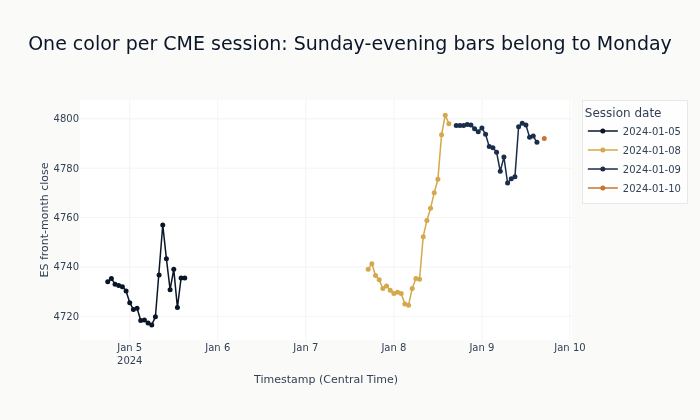

In [11]:
_boundary_window = (
    hourly_with_sessions.filter(
        (pl.col("product") == "ES")
        & (pl.col("tenor") == 0)
        & (pl.col("timestamp").dt.date() >= pl.lit("2024-01-05").str.to_date())
        & (pl.col("timestamp").dt.date() <= pl.lit("2024-01-09").str.to_date())
    )
    .with_columns(pl.col("timestamp").dt.convert_time_zone("America/Chicago").alias("ts_ct"))
    .sort("timestamp")
)

_sessions = _boundary_window["session_date"].unique().sort().to_list()
_session_colors = dict(zip(_sessions, ml4t_palette(len(_sessions), categorical=True)))

fig = go.Figure()
for sess in _sessions:
    seg = _boundary_window.filter(pl.col("session_date") == sess)
    fig.add_trace(
        go.Scatter(
            x=seg["ts_ct"].to_list(),
            y=seg["close"].to_list(),
            mode="lines+markers",
            line=dict(color=_session_colors[sess], width=1.5),
            marker=dict(size=5),
            name=str(sess),
        )
    )
fig.update_layout(
    title="One color per CME session: Sunday-evening bars belong to Monday",
    xaxis_title="Timestamp (Central Time)",
    yaxis_title="ES front-month close",
    height=420,
    legend_title="Session date",
)
fig.show()

## 3b. Ratio Back-Adjustment

Databento's continuous contracts are **unadjusted** — price gaps at roll transitions
produce spurious returns (e.g., ES Mar 2020: -11.08% artificial gap). We apply
**ratio (multiplicative)** back-adjustment using `instrument_id` to detect roll points:

1. Detect where `instrument_id` changes between adjacent hourly bars
2. Compute ratio = new contract open / old contract close at each roll
3. Accumulate ratios backward (most recent prices stay unadjusted)
4. Multiply all OHLC prices by cumulative ratio

Ratio adjustment preserves **percentage returns** (critical for IC, momentum features,
and backtesting) unlike Panama (additive) which distorts returns for old data and can
push prices negative for commodities with large cumulative adjustments.

See [`06_futures_continuous`](06_futures_continuous.ipynb) for a teaching explanation of adjustment methods.

### Exkurs: Was versteht man unter Ratio Back-Adjustment?

**Ratio (multiplikative) Back-Adjustment** baut aus mehreren aneinandergereihten
Futures-Kontrakten eine glatte, kontinuierliche Preisreihe — indem am Rolltag
entstehende Preissprünge durch **Multiplikation mit einem Skalierungsfaktor**
eliminiert werden, statt durch Addition (das wäre die Panama-Methode).

**Das Kernproblem:** Am Rolltag wechselt man vom auslaufenden Kontrakt zum
nächsten — die beiden notieren aber meist zu unterschiedlichen Preisen
(Contango/Backwardation). Ohne Anpassung sähe das im Chart wie ein
künstlicher Kurssprung aus, der keine echte Marktbewegung ist.

**So setzt der Code das um:**

1. **Ratio am Rolltag berechnen** (`roll_ratios` unten): neuer Kontrakt-Open
   geteilt durch alten Kontrakt-Close (`open / _prev_close`) — dieses
   Verhältnis beschreibt exakt den Preissprung am Rollpunkt.
2. **Rückwärts kumulieren** (`ratio_adjust()` weiter unten): Die Schleife
   läuft rückwärts durch die Zeit. Der jüngste Preis bleibt unangetastet
   (Faktor 1,0), und je weiter man in die Vergangenheit geht, desto mehr
   Rollfaktoren werden aufmultipliziert — das Ergebnis ist `_cumulative_ratio`.
3. **Alle historischen Preise skalieren**: `adj_close = close *
   _cumulative_ratio` — nicht *addiert*, sondern **multipliziert**, das ist
   der namensgebende Unterschied zur Panama-Methode.

**Warum multiplikativ statt additiv?** Multiplikation erhält **prozentuale
Renditen** korrekt über die gesamte Historie hinweg — dieselbe Logik wie beim
`raw_cumret`/`adj_cumret`-Vergleich in `02_corporate_actions.py`: Genau wie
dort Aktiensplits die Rendite-Kette verfälschen, verfälschen hier
Futures-Rolls sie, wenn man ihnen nicht mit einem multiplikativen Faktor
begegnet. Additive Anpassung (Panama) verzerrt dagegen Prozent-Renditen vor
allem bei alten, tief liegenden Preisen — dafür erhält sie exakte
Dollar-P&L-Beträge, was für Backtesting oft wichtiger ist.

**Reconciliation:** Der kumulative Faktor wird nicht verworfen, sondern als
eigene Spalte (`cum_ratio`) mitgeführt — so lässt sich jederzeit zwischen roh
und adjustiert hin- und herrechnen: `adj_close == raw_close * cum_ratio`,
ohne Informationsverlust.

In [12]:
# Sort and detect roll transitions per (product, tenor)
hourly_sorted = hourly_with_sessions.sort(["product", "tenor", "timestamp"])

# Detect instrument_id changes within each (product, tenor) group
hourly_sorted = hourly_sorted.with_columns(
    pl.col("instrument_id").shift(1).over("product", "tenor").alias("_prev_instrument_id"),
    pl.col("close").shift(1).over("product", "tenor").alias("_prev_close"),
)

# Roll points: where instrument_id changes (excluding first row of each group)
rolls = hourly_sorted.filter(
    pl.col("_prev_instrument_id").is_not_null()
    & (pl.col("instrument_id") != pl.col("_prev_instrument_id"))
)

# Ratio = new contract's open / old contract's close (adjacent hourly bars)
roll_ratios = rolls.select(
    "product",
    "tenor",
    "timestamp",
    (pl.col("open") / pl.col("_prev_close")).alias("ratio"),
)

print(f"Roll transitions detected: {len(roll_ratios)}")
print(f"Products with rolls: {roll_ratios['product'].n_unique()}")

# Front month (tenor 0) only — its ~quarterly rolls are what the adjusted
# front-month series below is built from. Deferred tenors roll far more often
# (thin volume flips leadership back and forth), so mixing tenors here would
# overstate the front-month roll count.
es_rolls = roll_ratios.filter((pl.col("product") == "ES") & (pl.col("tenor") == 0)).sort(
    "timestamp"
)
print(f"ES front-month roll ratios ({len(es_rolls)} rolls):")
es_rolls.select("timestamp", "ratio").head(10)

Roll transitions detected: 11295
Products with rolls: 14
ES front-month roll ratios (60 rolls):


timestamp,ratio
"datetime[ns, UTC]",f64
2011-03-14 00:00:00 UTC,0.99653
2011-06-13 00:00:00 UTC,0.995863
2011-09-12 00:00:00 UTC,0.994991
2011-12-12 00:00:00 UTC,0.995624
2012-03-13 00:00:00 UTC,0.995813
2012-06-11 00:00:00 UTC,0.994979
2012-09-17 00:00:00 UTC,0.995555
2012-12-17 00:00:00 UTC,0.995781
2013-03-12 00:00:00 UTC,0.996465


### Ratio Back-Adjustment Function

Walk backward through each (product, tenor) group, accumulating roll ratios to
build a cumulative multiplier for all OHLC prices.

In [13]:
def ratio_adjust(group: pl.DataFrame) -> pl.DataFrame:
    """Apply ratio back-adjustment to a single (product, tenor) group."""
    group = group.sort("timestamp")

    # Get roll ratios for this group
    group_rolls = roll_ratios.filter(
        (pl.col("product") == group["product"][0]) & (pl.col("tenor") == group["tenor"][0])
    ).select("timestamp", "ratio")

    if len(group_rolls) == 0:
        return group.with_columns(pl.lit(1.0).alias("_cumulative_ratio"))

    # Join roll ratios
    group = group.join(group_rolls, on="timestamp", how="left").with_columns(
        pl.col("ratio").fill_null(1.0)
    )

    # Cumulative ratio: product of all FUTURE ratios (reverse cumprod)
    # Bars BEFORE a roll get multiplied; bars ON and AFTER the roll do not
    n = len(group)
    ratios = group["ratio"].to_numpy()
    adj = np.ones(n)
    cumulative = 1.0
    for i in range(n - 1, -1, -1):
        adj[i] = cumulative
        if ratios[i] != 1.0:
            cumulative *= ratios[i]

    return group.with_columns(pl.Series("_cumulative_ratio", adj)).drop("ratio")

In [14]:
# Apply per group
adjusted_groups = []
products_tenors = hourly_sorted.select("product", "tenor").unique().sort("product", "tenor")
n_groups = len(products_tenors)

for i, row in enumerate(products_tenors.iter_rows(named=True)):
    group = hourly_sorted.filter(
        (pl.col("product") == row["product"]) & (pl.col("tenor") == row["tenor"])
    )
    adjusted = ratio_adjust(group)
    adjusted_groups.append(adjusted)
    if (i + 1) % 30 == 0 or i == n_groups - 1:
        print(f"  Adjusted {i + 1}/{n_groups} groups")

hourly_adjusted = pl.concat(adjusted_groups)

# Emit two explicit price series and NO bare OHLC. Ratio adjustment preserves
# within-tenor *returns* but distorts price *levels*: differencing adjusted
# tenor-0/tenor-1 levels reads accumulated roll history, not the curve. Every
# downstream consumer must name which series it wants:
#   - adj_* (returns / momentum / volatility / labels — roll-continuous)
#   - raw_* (carry / term structure / roll yield / notional / costs — contemporaneous)
# cum_ratio is carried through so the two are reconcilable (adj_close == raw_close * cum_ratio).
# Dropping bare open/high/low/close makes the adjusted-vs-raw choice impossible to skip.
hourly_adjusted = hourly_adjusted.with_columns(
    pl.col("open").alias("raw_open"),
    pl.col("high").alias("raw_high"),
    pl.col("low").alias("raw_low"),
    pl.col("close").alias("raw_close"),
)

# Adjusted OHLC (multiply by cumulative ratio, not add).
hourly_adjusted = hourly_adjusted.with_columns(
    (pl.col("open") * pl.col("_cumulative_ratio")).alias("adj_open"),
    (pl.col("high") * pl.col("_cumulative_ratio")).alias("adj_high"),
    (pl.col("low") * pl.col("_cumulative_ratio")).alias("adj_low"),
    (pl.col("close") * pl.col("_cumulative_ratio")).alias("adj_close"),
).drop("open", "high", "low", "close")

print(f"\nRatio adjustment applied to {len(hourly_adjusted):,} hourly bars")

# Show adjustment magnitude for ES front month
es_adj = hourly_adjusted.filter((pl.col("product") == "ES") & (pl.col("tenor") == 0)).sort(
    "timestamp"
)
print(
    f"ES front month cumulative ratio range: "
    f"{es_adj['_cumulative_ratio'].min():.4f} to {es_adj['_cumulative_ratio'].max():.4f}"
)

  Adjusted 30/42 groups
  Adjusted 42/42 groups

Ratio adjustment applied to 2,672,391 hourly bars
ES front month cumulative ratio range: 1.0000 to 1.1468


The adjustment is easiest to see side by side. The top panel plots the raw
(unadjusted) ES front-month close against the ratio-adjusted series; the two
coincide at the right edge (recent prices are the anchor) and separate going
back in time as each roll's ratio compounds. The bottom panel is that
cumulative multiplier — every downward step is a roll where the new contract
opened below the old one's close. Raw prices carry those roll gaps as spurious
returns; the adjusted series does not.

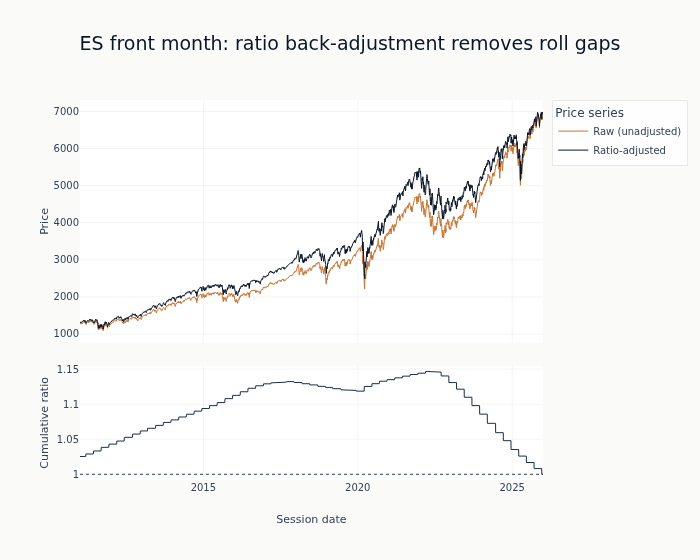

In [15]:
es_adj_daily = (
    es_adj.group_by("session_date")
    .agg(
        pl.col("raw_close").last(),
        pl.col("adj_close").last(),
        pl.col("_cumulative_ratio").last().alias("cum_ratio"),
    )
    .sort("session_date")
)
_x = es_adj_daily["session_date"].to_list()

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.68, 0.32],
    vertical_spacing=0.06,
)
fig.add_trace(
    go.Scatter(
        x=_x,
        y=es_adj_daily["raw_close"].to_list(),
        mode="lines",
        line=dict(color=COLORS["copper"], width=1),
        name="Raw (unadjusted)",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=_x,
        y=es_adj_daily["adj_close"].to_list(),
        mode="lines",
        line=dict(color=COLORS["blue"], width=1),
        name="Ratio-adjusted",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=_x,
        y=es_adj_daily["cum_ratio"].to_list(),
        mode="lines",
        line=dict(color=COLORS["slate"], width=1),
        name="Cumulative ratio",
        showlegend=False,
    ),
    row=2,
    col=1,
)
fig.add_hline(y=1.0, line=dict(color=COLORS["neutral"], width=1, dash="dot"), row=2, col=1)
fig.update_layout(
    title="ES front month: ratio back-adjustment removes roll gaps",
    height=560,
    legend_title="Price series",
)
fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Cumulative ratio", row=2, col=1)
fig.update_xaxes(title_text="Session date", row=2, col=1)
fig.show()

In [16]:
# Replace hourly_with_sessions with adjusted data for downstream aggregation.
# Keep the cumulative ratio (as cum_ratio) so raw and adjusted stay reconcilable.
hourly_with_sessions = hourly_adjusted.drop("_prev_instrument_id", "_prev_close").rename(
    {"_cumulative_ratio": "cum_ratio"}
)

## 4. Aggregate to Daily OHLCV

Aggregate hourly bars to daily using session boundaries. Both the adjusted
(`adj_*`) and raw (`raw_*`) series are aggregated the same way:
- **Open**: First bar's open
- **High**: Maximum high
- **Low**: Minimum low
- **Close**: Last bar's close
- **Volume**: Sum of all volumes

In [17]:
# Aggregate to daily by session_date, product, tenor
daily = (
    hourly_with_sessions.sort(["product", "tenor", "timestamp"])
    .group_by(["session_date", "product", "tenor"])
    .agg(
        [
            pl.col("adj_open").first(),
            pl.col("adj_high").max(),
            pl.col("adj_low").min(),
            pl.col("adj_close").last(),
            pl.col("raw_open").first(),
            pl.col("raw_high").max(),
            pl.col("raw_low").min(),
            pl.col("raw_close").last(),
            pl.col("cum_ratio").last(),
            pl.col("volume").sum(),
            pl.len().alias("bar_count"),
            pl.col("timestamp").min().alias("session_start"),
            pl.col("timestamp").max().alias("session_end"),
        ]
    )
    .sort(["product", "tenor", "session_date"])
)

print(f"Daily bars: {len(daily):,}")
print(f"Products: {daily['product'].n_unique()}")
print(f"Session date range: {daily['session_date'].min()} to {daily['session_date'].max()}")

Daily bars: 136,867
Products: 14
Session date range: 2011-01-03 to 2025-12-31


In [18]:
es_daily = daily.filter((pl.col("product") == "ES") & (pl.col("tenor") == 0))
print("ES front month daily bars (first 20 sessions):")
es_daily.select(
    "session_date", "adj_open", "adj_high", "adj_low", "adj_close", "volume", "bar_count"
).head(20)

ES front month daily bars (first 20 sessions):


session_date,adj_open,adj_high,adj_low,adj_close,volume,bar_count
date,f64,f64,f64,f64,u64,u32
2011-01-03,1287.915027,1304.834293,1287.145969,1297.656422,1596140,23
2011-01-04,1297.656422,1302.270768,1290.222199,1297.656422,1764094,24
2011-01-05,1297.656422,1306.116055,1287.658674,1303.55253,1784553,24
2011-01-06,1303.55253,1309.448638,1298.42548,1302.014415,1597347,24
2011-01-07,1302.014415,1306.372408,1289.709494,1299.45089,2166280,24
…,…,…,…,…,…,…
2011-01-24,1312.012163,1322.522616,1310.217695,1320.471796,1639436,23
2011-01-25,1320.471796,1324.573436,1309.448638,1319.702738,2359940,24
2011-01-26,1319.446386,1329.700486,1318.677328,1326.111551,1611687,24


## 5. Validate Aggregation

Check that daily aggregation is correct:
- Bar counts should be ~23 per session (23-hour trading day)
- OHLC relationships should hold (Low ≤ Open/Close ≤ High)

Typical sessions (20-24 bars): 97,813 / 136,867


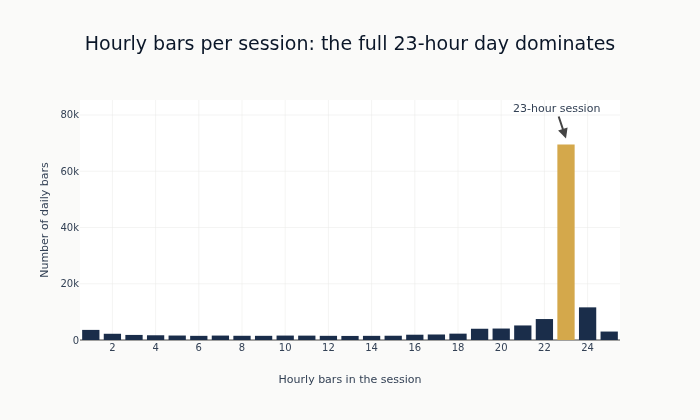

In [19]:
bar_counts = daily.group_by("bar_count").len().sort("bar_count")
typical_sessions = daily.filter(pl.col("bar_count").is_between(20, 24))
print(f"Typical sessions (20-24 bars): {len(typical_sessions):,} / {len(daily):,}")

# Highlight the modal (most common) bucket; a full 23-hour session dominates.
_modal_bars = bar_counts.sort("len", descending=True)["bar_count"][0]
fig = go.Figure(
    go.Bar(
        x=bar_counts["bar_count"].to_list(),
        y=bar_counts["len"].to_list(),
        marker_color=[
            COLORS["amber"] if bc == _modal_bars else COLORS["slate"]
            for bc in bar_counts["bar_count"].to_list()
        ],
    )
)
fig.add_annotation(
    x=_modal_bars,
    y=bar_counts.filter(pl.col("bar_count") == _modal_bars)["len"][0],
    text=f"{_modal_bars}-hour session",
    showarrow=True,
    arrowhead=2,
    yshift=6,
)
fig.update_layout(
    title="Hourly bars per session: the full 23-hour day dominates",
    xaxis_title="Hourly bars in the session",
    yaxis_title="Number of daily bars",
    height=420,
    showlegend=False,
    xaxis=dict(dtick=2),
)
fig.show()

In [20]:
# OHLC invariant check
ohlc_check = daily.with_columns(
    [
        (pl.col("adj_low") <= pl.col("adj_open")).alias("low_le_open"),
        (pl.col("adj_low") <= pl.col("adj_close")).alias("low_le_close"),
        (pl.col("adj_high") >= pl.col("adj_open")).alias("high_ge_open"),
        (pl.col("adj_high") >= pl.col("adj_close")).alias("high_ge_close"),
    ]
)

print("OHLC Invariant Check:")
for col in ["low_le_open", "low_le_close", "high_ge_open", "high_ge_close"]:
    pct = ohlc_check[col].mean() * 100
    status = "[OK]" if pct > 99.9 else "[FAIL]"
    print(f"  {status} {col}: {pct:.2f}%")

OHLC Invariant Check:
  [OK] low_le_open: 100.00%
  [OK] low_le_close: 100.00%
  [OK] high_ge_open: 100.00%
  [OK] high_ge_close: 100.00%


## 6. Coverage Summary

Summary of daily data coverage by product.

In [21]:
# Coverage by product
coverage = (
    daily.group_by("product")
    .agg(
        [
            pl.col("session_date").min().alias("start_date"),
            pl.col("session_date").max().alias("end_date"),
            pl.len().alias("total_bars"),
            pl.col("tenor").n_unique().alias("tenors"),
        ]
    )
    .sort("product")
)

print("Daily data coverage by product:")
coverage

Daily data coverage by product:


product,start_date,end_date,total_bars,tenors
str,date,date,u32,u32
"""CL""",2011-01-03,2025-12-31,11606,3
"""ES""",2011-01-03,2025-12-31,11349,3
"""GC""",2011-01-03,2025-12-31,11591,3
"""HO""",2011-01-03,2025-12-31,11601,3
"""NG""",2011-01-03,2025-12-31,11607,3
…,…,…,…,…
"""YM""",2011-01-03,2025-12-31,9589,3
"""ZB""",2011-01-03,2025-12-31,8472,3
"""ZF""",2011-01-03,2025-12-31,7370,3


In [22]:
tenor_coverage = (
    daily.group_by("tenor")
    .agg(
        pl.col("product").n_unique().alias("products"),
        pl.len().alias("total_bars"),
    )
    .sort("tenor")
)
print("Coverage by tenor:")
tenor_coverage

Coverage by tenor:


tenor,products,total_bars
i8,u32,u32
0,14,52459
1,14,51055
2,14,33353


## 7. Save Daily Data

Save the session-aggregated daily data for downstream use.

In [23]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save combined daily file
output_path = OUTPUT_DIR / "continuous_daily.parquet"
daily.write_parquet(output_path)
print(f"Saved: {_rel(output_path)}")
print(f"Size: {output_path.stat().st_size / 1e6:.1f} MB")

Saved: 02_financial_data_universe/output/futures_daily/continuous_daily.parquet
Size: 6.6 MB


In [24]:
# Also save per-product files for convenience
per_product_dir = OUTPUT_DIR / "by_product"
per_product_dir.mkdir(exist_ok=True)

for product in products:
    product_df = daily.filter(pl.col("product") == product)
    product_path = per_product_dir / f"{product}.parquet"
    product_df.write_parquet(product_path)

print(f"\nSaved per-product files to: {_rel(per_product_dir)}/")
print(f"Products: {len(products)}")


Saved per-product files to: 02_financial_data_universe/output/futures_daily/by_product/
Products: 14


## 8. Using the Daily Data

The daily data is now available via `load_cme_futures()` (daily is the default frequency).
This loader is defined in `data/__init__.py` and can be used by downstream chapters.

In [25]:
es_nq_2024 = (
    pl.read_parquet(OUTPUT_DIR / "continuous_daily.parquet")
    .filter(
        pl.col("product").is_in(["ES", "NQ"])
        & (pl.col("tenor") == 0)
        & (pl.col("session_date") >= pl.lit("2024-01-01").str.to_date())
        & (pl.col("session_date") <= pl.lit("2024-12-31").str.to_date())
    )
    .sort("session_date", "product")
)
print(f"ES + NQ front month, 2024: {len(es_nq_2024)} daily bars")
es_nq_2024.head(10)

ES + NQ front month, 2024: 518 daily bars


session_date,product,tenor,adj_open,adj_high,adj_low,adj_close,raw_open,raw_high,raw_low,raw_close,cum_ratio,volume,bar_count,session_start,session_end
date,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,u64,u32,"datetime[ns, UTC]","datetime[ns, UTC]"
2024-01-02,"""ES""",0,5231.500081,5242.358321,5174.494321,5199.468273,4818.0,4828.0,4765.5,4788.5,1.085824,1549005,23,2024-01-01 23:00:00 UTC,2024-01-02 21:00:00 UTC
2024-01-02,"""NQ""",0,18663.756856,18685.141383,18228.938148,18348.746329,17019.0,17038.5,16622.5,16731.75,1.096642,634193,23,2024-01-01 23:00:00 UTC,2024-01-02 21:00:00 UTC
2024-01-03,"""ES""",0,5201.911377,5201.911377,5147.891632,5156.306768,4790.75,4790.75,4741.0,4748.75,1.085824,1587336,23,2024-01-02 23:00:00 UTC,2024-01-03 21:00:00 UTC
2024-01-03,"""NQ""",0,18354.229541,18354.777862,18118.725588,18141.480917,16736.75,16737.25,16522.0,16542.75,1.096642,668346,23,2024-01-02 23:00:00 UTC,2024-01-03 21:00:00 UTC
2024-01-04,"""ES""",0,5157.664048,5175.580145,5132.690096,5138.390672,4750.0,4766.5,4727.0,4732.25,1.085824,1299377,23,2024-01-03 23:00:00 UTC,2024-01-04 21:00:00 UTC
2024-01-04,"""NQ""",0,18144.222523,18190.281504,18024.414342,18040.589817,16545.25,16587.25,16436.0,16450.75,1.096642,551255,23,2024-01-03 23:00:00 UTC,2024-01-04 21:00:00 UTC
2024-01-05,"""ES""",0,5138.933584,5168.793745,5105.544496,5141.9196,4732.75,4760.25,4702.0,4735.5,1.085824,1663860,23,2024-01-04 23:00:00 UTC,2024-01-05 21:00:00 UTC
2024-01-05,"""NQ""",0,18045.250548,18179.31508,17912.830979,18056.216971,16455.0,16577.25,16334.25,16465.0,1.096642,620632,23,2024-01-04 23:00:00 UTC,2024-01-05 21:00:00 UTC
2024-01-08,"""ES""",0,5142.191056,5215.484177,5119.931664,5209.783601,4735.75,4803.25,4715.25,4798.0,1.085824,1339989,23,2024-01-07 23:00:00 UTC,2024-01-08 21:00:00 UTC


## Key Takeaways

1. **CME sessions end at 4 PM CT**, not midnight UTC. The session date is
   the date the session ends — Sunday-evening trading belongs to Monday's
   session.
2. **Volume here is 5,463,741 hourly bars across 30 products and 3 tenors**,
   aggregating to 312,859 daily bars over 2011-01-03 through 2025-12-31.
3. **Ratio back-adjustment** is applied per (product, tenor) before
   aggregation — for ES front month the cumulative ratio ranges 0.87–1.16
   over its 62 (roughly quarterly) rolls, preserving percentage returns
   across roll boundaries.
4. **Full sessions have 23 hourly bars** (23-hour trading day): the 23-bar
   bucket is by far the largest in the bar-count distribution. Shorter
   sessions arise from holidays, deferred tenors with thin trading, and
   partial days.
5. **OHLC invariants hold at 100%** on the aggregated daily bars across all
   four checks.

## Next Steps

- [`06_futures_continuous`](06_futures_continuous.ipynb): Roll detection and
  alternative adjustment methods (Panama / calendar).
- **Chapter 8**: Feature engineering on daily futures data.
- **Chapter 16**: Backtesting with session-correct returns.